# Q learning : application

Dans cette séance on testera l'algorithme de Q learning avec un environnement de simulation d'OpenAI gymnasium (anciennement gym)

https://gymnasium.farama.org/

### Quelques installations

Selon ce qui est déjà installé dans votre environnement de travail, vous aurez besoin de quelques librairies.

In [1]:
%pip -q install --upgrade pip
%pip -q install ipywidgets numpy ffmpeg ffmpeg-python swig

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip -q install ufal.pybox2d
%pip -q install gymnasium

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.animation as animation
import matplotlib.cm as cm

In [4]:
# pour lire des videos locales facilement
from base64 import b64encode
from IPython.display import HTML

def play_video(v_path,width=400):
      mp4 = open(v_path,'rb').read()
      data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
      return HTML("""
          <video width=%d controls>
          <source src="%s" type="video/mp4">
          </video>
          """ % (width,data_url))

## Découverte des environnements d'OpenAI Gym

Gym définit des mondes dans lesquels on peut avoir un agent qui agit sur l'environnement, et avoir l'observation de certaines variables de cet environnement.

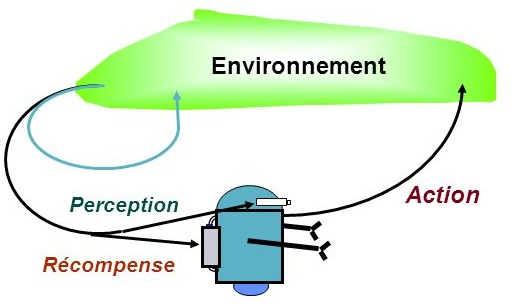




On utilisera plusieurs environnements, mais voyons déjà celui ci:
un module lunaire essaie d'atterrir en douceur sur un emplacement fixé

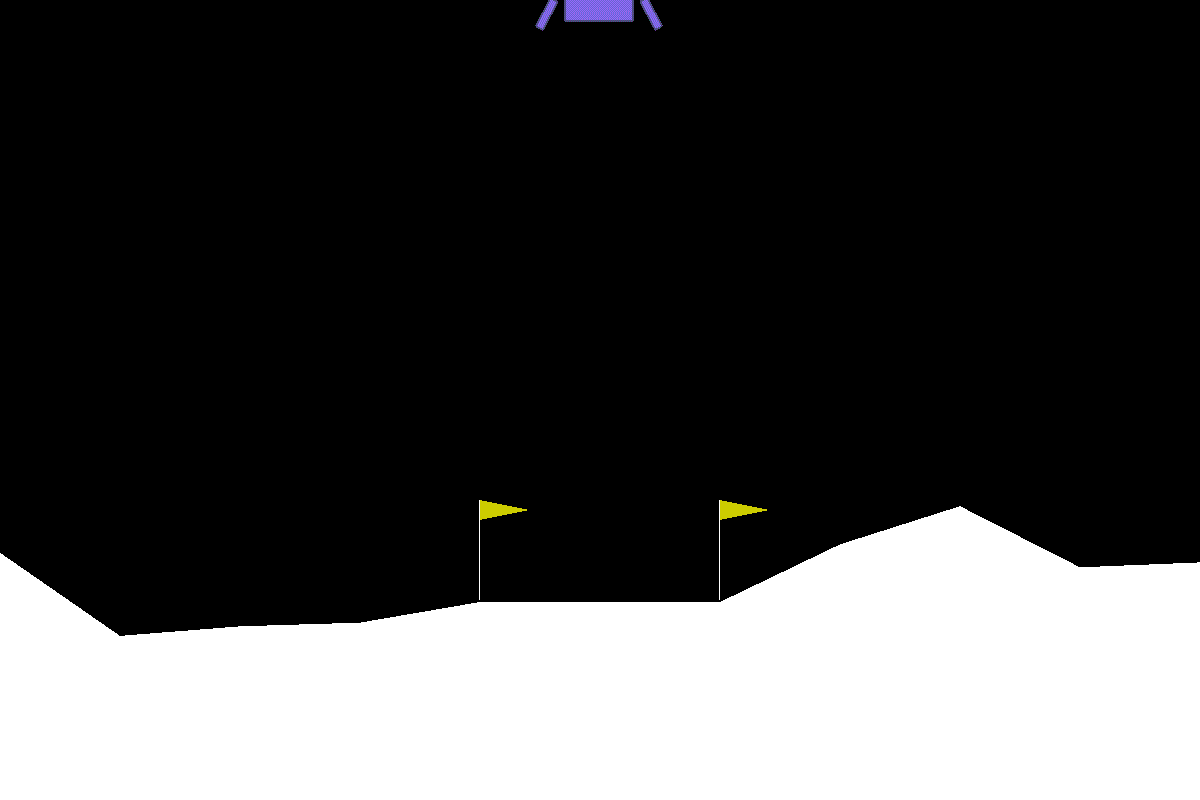

In [5]:
%pip -q install Box2D pygame

Note: you may need to restart the kernel to use updated packages.


 - On charge un environnement. `l'option render_mode` détermine le rendu visuel des simulations.
 - ici on sauvera des images
 - on a l'initialise sur un état de départ. 
    - -> renvoie une "observation" : un état de l'environnement

In [6]:
# Environment creation with render mode specified upfront
env = gym.make("LunarLander-v3",continuous=False, gravity=-10.0,enable_wind=False, wind_power=15.0, turbulence_power=1.5)
# on l'initialise sur un état de départ. -> renvoie une "observation" : un état de l'environnement
print("on l'initialise sur un état de départ", env.reset())

# on peut échantilloner une action au hasard
print( "action sampled :" ,env.action_space.sample())

on l'initialise sur un état de départ (array([ 7.8582764e-04,  1.4141991e+00,  7.9588592e-02,  1.4573409e-01,
       -9.0385799e-04, -1.8027997e-02,  0.0000000e+00,  0.0000000e+00],
      dtype=float32), {})
action sampled : 1


__Le LunarLander-v3 possède un espace d'états continu (8 variables) et un espace d'actions discret (4 actions).__.        
__Pour chaque environnement comprend, les actions disponibles.__

In [7]:
# Espace des actions : Nop, fire left engine, main engine, right engine
print("Espace des actions : Nop, fire left engine, main engine, right engine : " ,env.action_space)

Espace des actions : Nop, fire left engine, main engine, right engine :  Discrete(4)


__`Action 0 : Ne rien faire (do nothing)`__.  

__Aucun moteur n'est allumé__, 
- Le lander est soumis uniquement à la gravité et à l'inertie
- Utile pour économiser du carburant
- Le carburant soit infini dans cet environnement

__`Action 1 : Moteur d'orientation gauche (fire left orientation engine)`__

__Allume le propulseur latéral gauche__, 
- Fait pivoter le lander vers la droite (rotation horaire)
- Coût : -0.03 points par frame​
- Utilisé pour corriger l'angle lorsque le lander penche trop à gauche

__`Action 2 : Moteur principal (fire main engine)`__

__Allume le propulseur principal (orienté vers le bas)__
- Pousse le lander vers le haut, ralentissant la descente
- Coût : -0.3 points par frame​
- Le plus coûteux mais essentiel pour contrôler l'altitude et éviter un crash

__`Action 3 : Moteur d'orientation droit (fire right orientation engine)`__

__Allume le propulseur latéral droit__
- Fait pivoter le lander vers la gauche (rotation anti-horaire)
- Coût : -0.03 points par frame​
- Utilisé pour corriger l'angle lorsque le lander penche trop à droite

__`L'environnement définit un certain nombre de variables observables`__.

- observation[0] Position X (horizontal) - `cible à 0.0`. 
- observation[1] Position Y (hauteur) - `plus haut = mieux`.  
- observation[2] Vitesse Vx (horizontale) - `doit être proche de 0 à l'atterrissage`. 
- observation[3] Vitesse Vy (verticale) - `doit être faible (descente douce)`.  
- observation[4] Angle theta (en radians) - `doit être proche de 0 (vertical)`. 
- observation[5] Vitesse angulaire theta_dot - `doit être proche de 0`.  
- observation[6] Contact jambe gauche `(0 ou 1)`. 
- observation[7] Contact jambe droite `(0 ou 1)`.  


__`A chaque action faite par un agent :`__ 

- l'environnement informe sur le nouvel état, 
- donne une récompense (prédéfinie et fixé pour chaque monde), 
- renvoie aussi une condition qui précise si la simulation est finie (crash ou atterrissage réussi).

In [8]:
#faire une action, constater l'état suivant, reward etc
for i in range(4): 
    observation, reward, done, truncated, info = env.step(i)
    print(f'X : {observation[0]:.4f} Y : {observation[1]:.4f} Vx : {observation[2]:.4f} Vy : {observation[3]:.4f} theta : {observation[4]:.4f} theta_dot : {observation[5]:.4f} - JG : : {observation[6]:.4f}, JD : {observation[7]:.4f}')   

X : 0.0016 Y : 1.4169 Vx : 0.0795 Vy : 0.1200 theta : -0.0018 theta_dot : -0.0178 - JG : : 0.0000, JD : 0.0000
X : 0.0023 Y : 1.4190 Vx : 0.0689 Vy : 0.0939 theta : -0.0006 theta_dot : 0.0245 - JG : : 0.0000, JD : 0.0000
X : 0.0028 Y : 1.4218 Vx : 0.0530 Vy : 0.1247 theta : -0.0002 theta_dot : 0.0083 - JG : : 0.0000, JD : 0.0000
X : 0.0034 Y : 1.4240 Vx : 0.0626 Vy : 0.0981 theta : -0.0017 theta_dot : -0.0301 - JG : : 0.0000, JD : 0.0000


In [9]:
%pip -q install moviepy

Note: you may need to restart the kernel to use updated packages.


## I) Ecrire une fonction de simulation

 - `Elle produit une séquence d'action au hasard`
 - `Elle enregistre les récompenses et la trajectoire de chaque variable observée`.


In [10]:
# version à compléter
def random_sequence(env, buffer_length):
        trajectory= []
        observation, _ = env.reset(seed=42)
        # sauve les observations pour faire des stats
        trajectory.append(observation)
        # somme des renforcements
        reward = 0    
        print(f'etape - 0  reward : {reward:.4f} - (X: {observation[0]:.4f}, Y: {observation[1]:.4f}) - (Vx: {observation[2]:.4f}, Vy: {observation[3]:.4f}) - (theta : {observation[4]:.4f}, theta_dot: {observation[5]:.4f}) JG : {observation[6]:.4f} - JD : {observation[7]:.4f}')   
        t=0
        done = False
        while not done:
            action = env.action_space.sample()
            observation, reward, terminated, truncated, info = env.step(action)
            print(f'etape - {action} reward : {reward:.4f} - (X: {observation[0]:.4f}, Y: {observation[1]:.4f}) - (Vx: {observation[2]:.4f}, Vy: {observation[3]:.4f}) - (theta: {observation[4]:.4f}, theta_dot: {observation[5]:.4f}) JG: {observation[6]:.4f} - JD: {observation[7]:.4f}')          
            trajectory.append(observation)
            reward += reward
            t+=1
            if t >= buffer_length:
                break
            done = terminated or truncated
        env.close()
        return reward, trajectory

In [ ]:
import os
import glob
import time
import warnings
warnings.filterwarnings('ignore')

t = time.localtime()
current_time = time.strftime("%H%M%S", time.localtime())

_PATH_ ="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP3/lunar-lander/"
_FILE_ = "eval-episode-0.mp4"
PATH   = _PATH_ + _FILE_
# voilà comment créer l'environnement pour avoir accès à une simulation d'épisode et les stats d'un épisode
# un nouvel épisode est créé à chaque env.reset(), et stocké.

env = gym.make("LunarLander-v3",continuous=False, gravity=-11,
               enable_wind=False, wind_power=0, turbulence_power=0,
               render_mode="rgb_array")

# Supprimer les anciennes vidéos
for video_file in glob.glob(f"{_FILE_}"):
    os.remove(video_file)

env = RecordVideo(env, video_folder=_PATH_, name_prefix="eval", episode_trigger=lambda x: True)
buffer_length=200
env = RecordEpisodeStatistics(env, buffer_length=buffer_length)
total, trajectory = random_sequence(env,buffer_length)
print("total reward = ", total)
print(f'Episode time taken: {env.time_queue}')
print(f'Episode total rewards: {env.return_queue}')
print(f'Episode lengths: {env.length_queue}')
# une video a du être créée pour chaque épisode (ici un seul)
play_video(PATH,width=600)

etape - 0  reward : 0.0000 - (X: 0.0023, Y: 1.4181) - (Vx: 0.2326, Vy: 0.3178) - (theta : -0.0027, theta_dot: -0.0527) JG : 0.0000 - JD : 0.0000
etape - 0 reward : 1.3589 - (X: 0.0046, Y: 1.4246) - (Vx: 0.2323, Vy: 0.2894) - (theta: -0.0053, theta_dot: -0.0521) JG: 0.0000 - JD: 0.0000
etape - 0 reward : 1.3893 - (X: 0.0069, Y: 1.4304) - (Vx: 0.2323, Vy: 0.2601) - (theta: -0.0079, theta_dot: -0.0521) JG: 0.0000 - JD: 0.0000
etape - 3 reward : 0.4632 - (X: 0.0093, Y: 1.4356) - (Vx: 0.2415, Vy: 0.2310) - (theta: -0.0123, theta_dot: -0.0887) JG: 0.0000 - JD: 0.0000
etape - 0 reward : 1.0563 - (X: 0.0116, Y: 1.4402) - (Vx: 0.2415, Vy: 0.2017) - (theta: -0.0167, theta_dot: -0.0887) JG: 0.0000 - JD: 0.0000
etape - 1 reward : 2.0499 - (X: 0.0139, Y: 1.4441) - (Vx: 0.2302, Vy: 0.1728) - (theta: -0.0189, theta_dot: -0.0431) JG: 0.0000 - JD: 0.0000
etape - 0 reward : 1.1185 - (X: 0.0162, Y: 1.4473) - (Vx: 0.2302, Vy: 0.1434) - (theta: -0.0210, theta_dot: -0.0431) JG: 0.0000 - JD: 0.0000
etape - 1

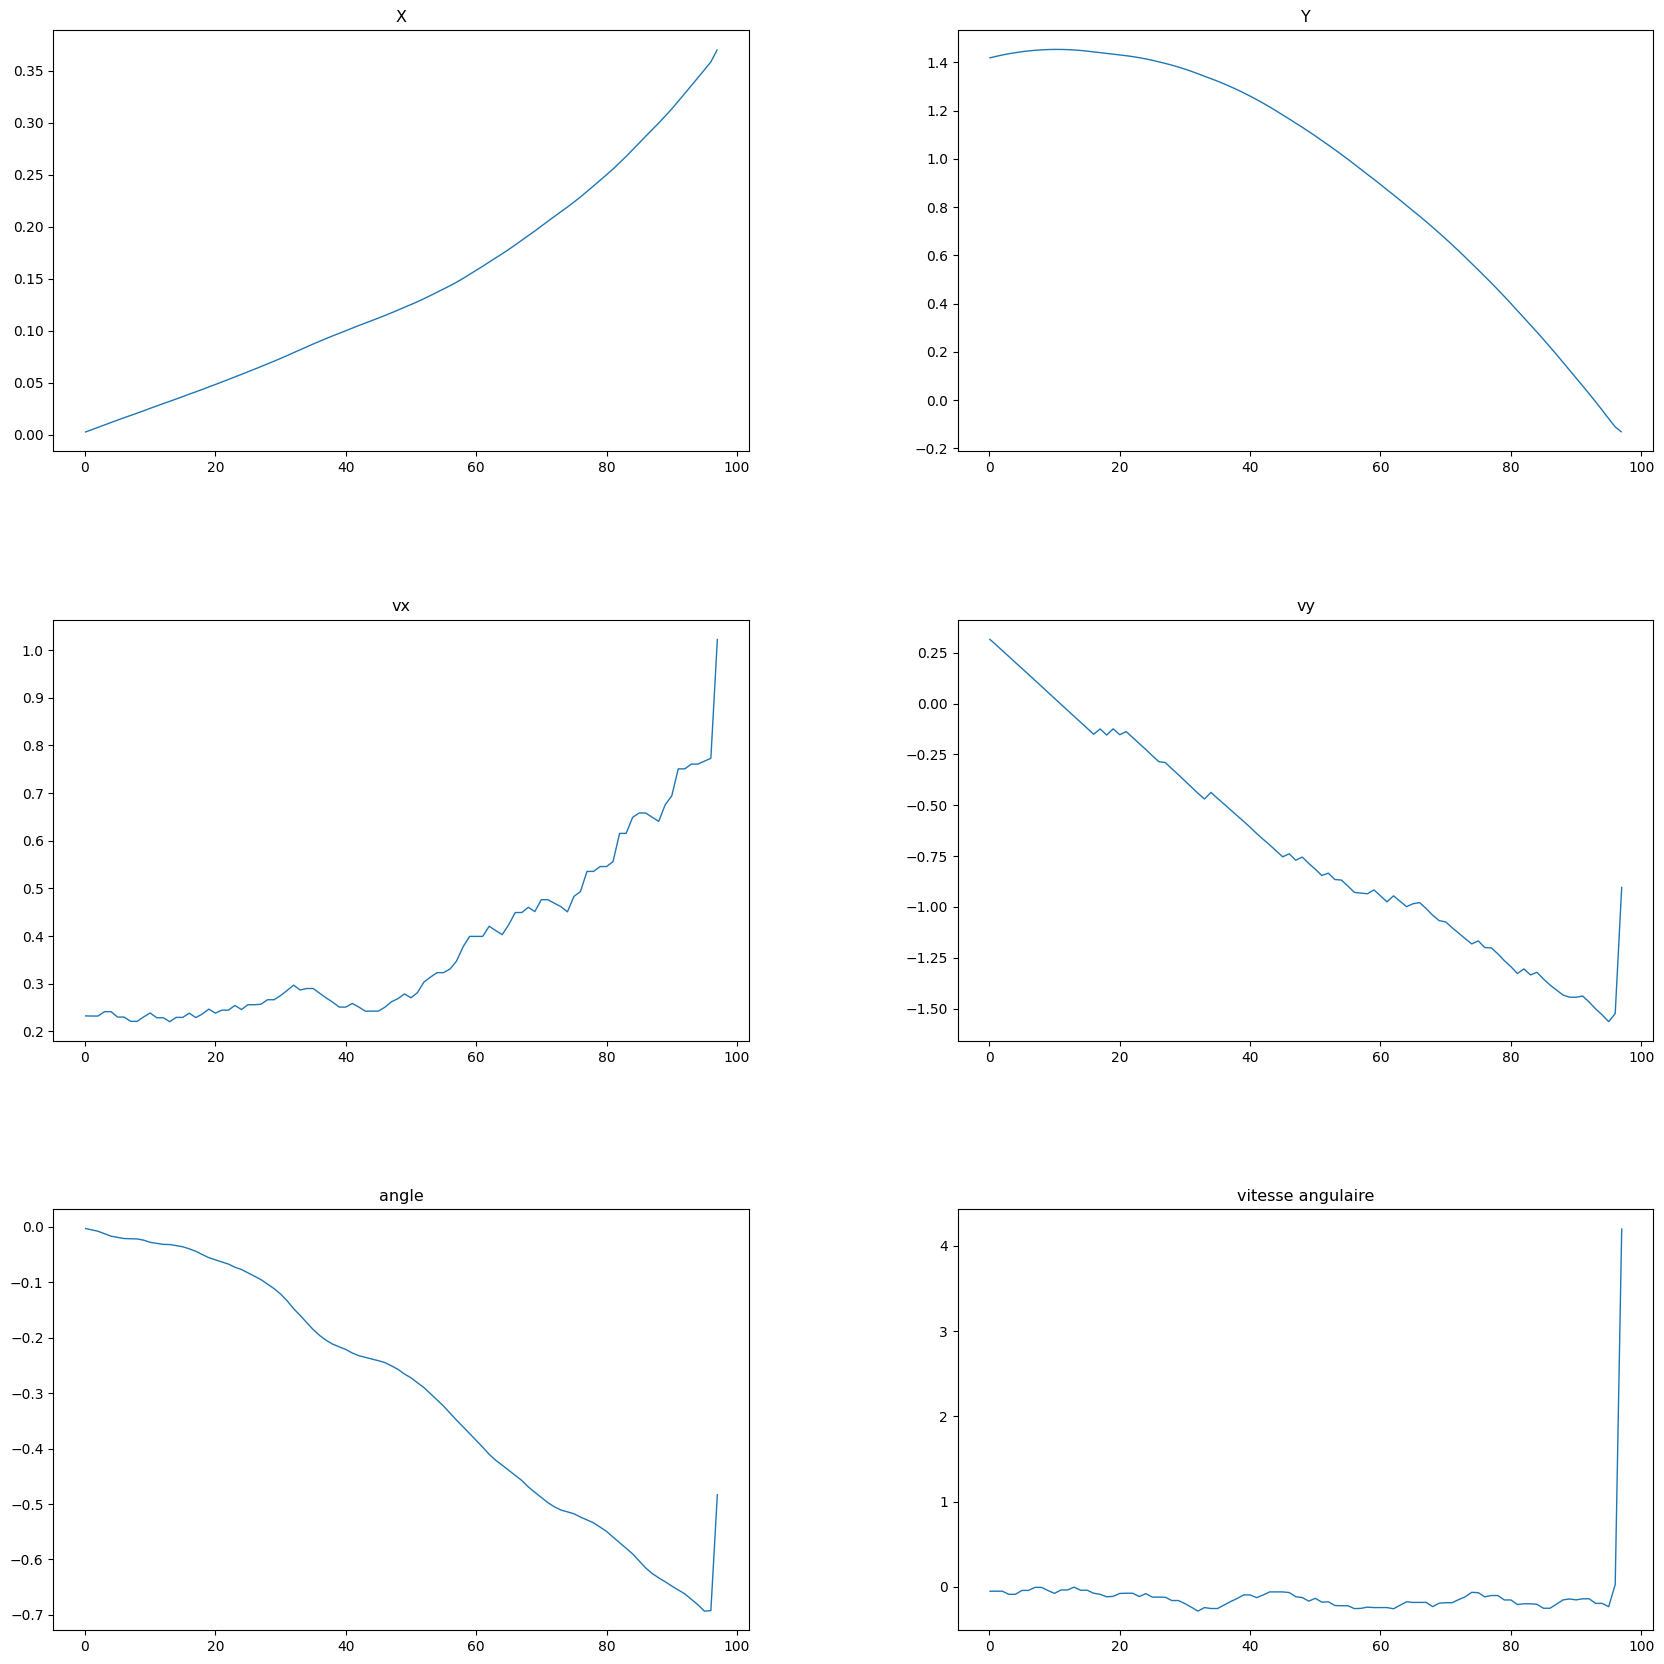

In [12]:
import numpy as np
# Convertir la liste trajectory en array NumPy
trajectory = np.array(trajectory)

# On peut observer l'évolution des variables au cours de la simulation
# Espace des observations
variables = {0:"X",1:"Y",   # Position X, Y
             2:"vx",3:"vy", # vecteur vitesse vx, vx
             4:"angle",     # / vertical
             5:"vitesse angulaire",
            }
%matplotlib inline
fig, axs = plt.subplots(3,2,figsize=(20, 20))
plt.style.use('fivethirtyeight')
plt.rcParams["figure.figsize"] = [13,8]
plt.rcParams['font.size'] = 8
plt.rcParams["figure.autolayout"] = True
fig.tight_layout()
for i in range(6):
    axs[i//2,i%2].set_title(variables[i])
    axs[i//2,i%2].plot(trajectory[:,i],linewidth=1) 
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.3, hspace=0.4)      
plt.show()    


## __`Environnement Frozen Lake`__

Nous allons d'abord expérimenter le Q-learning dans un environnement un peu plus simple avec peu d'états. 
L'environnement "frozen lake" au sein duquel nous allons apprendre à un agent à rejoindre son but en évitant de tomber dans l'eau.   

Le paramètre is_slippery détermine le comportement de l'environnement Frozen Lake :      

- is_slippery = False, le comportement est déterministe, 
- is_slippery = True, le comportement est stochastique.

`Principe d'optimalité de Bellman déterministe` .   

:::

Ce principe stipule que la valeur optimale d'un état dépend de la récompense immédiate et de la valeur optimale de l'état suivant 

$\large R(π,s) = r (s,π(s)) + γR(π,δ(s,π(s))$

  - $r(s,π(s))$ : récompense immédiate obtenue via l'action recommandée par la politique π dans l'état s.
  - $δ(s,π(s))$ : Le nouvel état atteint après avoir effectué l'action donnée par la politique π dans l'état s.
  - $\gamma$ : Le facteur d'actualisation, qui réduit l'importance des récompenses futures.
  - $\gamma R(π,δ(s,π(s)))$ : la récompense attendue à partir du nouvel état, pondéré par le facteur d'actualisation $γ$.

:::

:::

`Donne la vraie valeur optimale d’une paire (état, action)` 

$\large Q^{∗}(s,a)=r+ \gamma * \max_{a′} Q^{∗}(s',a')$

Récompense immédiate `r` + le retour MAX dans le futur, si l'on agit de façon optimale à partir de l’état suivant `s′`

:::

__Déterministe ou stochastique, la formule de mise à jour de la table Q est identique, seuls les valeurs des hyperparamètres diffèrent.__ 

:::

`Règle de mise à jour de Q-learning`

$\large Q(s,a)← (1 - \alpha)Q(s,a) + \alpha *[r + \gamma* \max_{a^′} Q(s^′,a^′)]$

 - __s__ : l’état où actuellement l'on se trouve
 - __a__ : l’action que nous choisissons depuis cet état
 - __s′__ : l’état où l'on arrive après avoir choisi l’action a
 - __r__ : la récompense donné par l’environnement lors de la transition (s,a)→s' 
     
:::

:::

$Q(s,a)$ : valeur actuelle estimée d'effectuer l’action $a$ dans l’état $s$.​   

 - $(1 − \alpha) Q(s,a)$ : on garde une partie de l’ancienne valeur (facteur d’oubli $1 − \alpha$).​
 - $r + \gamma* \max_{a^′} Q(s^′,a^′)$ : nouvelle cible = récompense immédiate + meilleur gain futur possible dans l’état suivant s, pondéré par γ.​
 - $\alpha$ : learning rate qui règle combien on se rapproche de cette cible à chaque mise à jour.

:::


:::

`La boucle classique :`

 - Initialiser Q-table (ou NN).  

__Pour chaque épisode:__

- Réinitialiser l'environnement : 
   - `state = env.reset()`
- Décroissance epsilon pour diminuer l'exploration au fil du temps
- Boucle de pas (jusqu'à atteindre l'objectif ou le nombre max de pas):
- Choisir l'action avec la politique epsilon-greedy
- Exécuter l'action: 
   - `new_state, reward, done, info = env.step(action)`
- Mettre à jour la Q-table avec la formule: 

:::

In [13]:
%pip -q install --upgrade stable-baselines3
%pip -q install --upgrade gymnasium

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


<div><img src="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP3/img/frozen_lake.gif" width="200"></div>

on peut customiser aussi en utilisant les codes :

S=start, G=goal, H=hole, F=frozen

In [14]:
desc4=["SFFF","FHFH","FFFH","HFFG"]
# Transitions non déterministes
env = gym.make('FrozenLake-v1', desc=desc4, is_slippery=False,render_mode="rgb_array")
env.reset()
# si aucune description ou map_name n'est donné un environnement est généré au hasard
# en forçant l'existence d'un chemin

(0, {'prob': 1})

In [15]:
def simulation(env, Qtable, max_steps=100):
    state, _ = env.reset()
    for step in range(max_steps):     
        action = np.argmax(Qtable[state])    
        state, reward, done, truncated, info = env.step(action)   
        if done or truncated:
            break
    return env.render()

on peut observer un environnement en l'affichant.

In [16]:
def image_render():
    image = env.render()
    plt.figure(figsize=(3, 3))
    plt.imshow(image) # type: ignore
    plt.axis('off') 
    plt.show()

### Explorer l'environnement

Vérifiez le nombre d'actions, essayer de trouver quel code correspond à quelle action en observant le résultat d'une action sur un environnement donné. 
 - L'espace d'action (Action Space) pour Frozen Lake est Discrete(4), ce qui signifie qu'il y a 4 actions possibles

Dans FrozenLake, chaque état est juste un numéro qui code la position de l’agent sur la grille.    
 - L’index est calculé par : __state = row × ncols + col__ 

`Regarder ce qui définit un état donné`

L'environnement se présente sous forme d'un grid world (grille) de dimension 4×4 par défaut, qui donne 16 états possibles.    
Chaque case de la grille correspond à un état distinct dans lequel l'agent peut se trouver. 

Les états sont numérotés de 0 à 15 pour la grille 4×4 :​
- L'état 0 correspond à la position de départ (case en haut à gauche, position )
- L'état 15 correspond à la position d'arrivée (case en bas à droite, position )​
- Les autres états représentent les cases intermédiaires, certaines étant gelée (F), d'autres des trous (H)

In [17]:
print("Espace des observations : ", env.observation_space.n) 
action_name = {0:"GAUCHE",
               1:"BAS",
               2:"DROITE",
               3:"HAUT"
              }

print(f"Espace des actions  : {env.action_space} : {action_name}\n") 

Espace des observations :  16
Espace des actions  : Discrete(4) : {0: 'GAUCHE', 1: 'BAS', 2: 'DROITE', 3: 'HAUT'}



In [18]:
#faire une action, constater l'état suivant, reward etc
for i in range(1,4): 
    observation, reward, done, truncated, info = env.step(i)
    print(f'Action : {action_name[i]} - Etat : {observation} - Reward : {reward} - Done : {done}')
    if done or truncated :
       env.reset()   

Action : BAS - Etat : 4 - Reward : 0 - Done : False
Action : DROITE - Etat : 5 - Reward : 0 - Done : True
Action : HAUT - Etat : 0 - Reward : 0 - Done : False


`Essayer de trouver les récompenses`.   

- reward schedule par défaut reward_schedule=(1, 0, 0)
  - Reach goal: +1
  - Reach hole: 0
  - Reach frozen: 0

In [19]:
def display_table_with_action_names(P, action_name):
    for state, actions in P.items():
        print(f"État {state}:")
        for action, transitions in actions.items():
            action_desc = action_name.get(action, f"Action {action}")
            print(f"  Action '{action_desc}':")
            for prob, next_state, reward, done in transitions:
                terminal_status = "Terminal" if done else "Non-terminal"
                print(f"    -> Probabilité: {prob:.2f}, État suivant: {next_state}, Récompense: {reward}, terminal_status : {terminal_status}")
        break

__`La variable P représente la fonction de transition de probabilités de l’environnement de type Markov Decision Process (MDP)`.__

In [20]:
P = env.env.env.env.P # type: ignore
display_table_with_action_names(P, action_name)

État 0:
  Action 'GAUCHE':
    -> Probabilité: 1.00, État suivant: 0, Récompense: 0, terminal_status : Non-terminal
  Action 'BAS':
    -> Probabilité: 1.00, État suivant: 4, Récompense: 0, terminal_status : Non-terminal
  Action 'DROITE':
    -> Probabilité: 1.00, État suivant: 1, Récompense: 0, terminal_status : Non-terminal
  Action 'HAUT':
    -> Probabilité: 1.00, État suivant: 0, Récompense: 0, terminal_status : Non-terminal


In [21]:
%pip -q install tqdm

Note: you may need to restart the kernel to use updated packages.


###  Q-learning      
Nous allons maintenant implémenter un apprentissage par Q-learning :
:::


### __En définissant une table Q avec numpy, quelles sont les options pour initialiser cette table?__
   
`Initialiser la table Q avec des valeurs nulles permet de commencer son apprentissage sans biais initial`
- Q_table = np.zeros((state_space, action_space))
       
`Initialisater la table Q avec de petites valeurs aléatoire,permet d'encourager l'exploration initiale` :  
- Q_table = np.random.uniform(low=0, high=0.01, size=(state_space, action_space))
    
`Initialisation optimiste basée sur l'application d'un facteur multiplicateur aux valeurs de la table`
  - Q_table = np.ones((state_space, action_space)) * optimistic_value
        
`Initialisation la table Q basée sur des connaissances préalables`
  - Q_table = np.array([...]) 
        
:::

In [22]:
def init_Qtable(nb_states,nb_actions,opts=True):
    if  opts : Q_table = np.zeros((nb_states,nb_actions)) 
    else : Q_table = np.random.uniform(low=0, high=0.01, size=(nb_states, nb_actions))
    return Q_table

`Apprentissage ε-greedy`
:::

La stratégie epsilon-greedy est utilisée dans l'apprentissage par renforcement pour équilibrer l'exploration et l'exploitation. 

__Principe de base de la stratégie epsilon-greedy fonctionne avec__ :

`Epsilon-decreasing :`   
  - Avec cette stratégie, la valeur de epsilon diminue progressivement au fur et à mesure que l'expérience progresse, favorisant une exploration plus importante au début et une exploitation accrue vers la fin.

`Epsilon-first :`   
 - Cette approche divise l'expérience en deux phases distinctes :
 
   - Une phase d'exploration pure ($\large \epsilon =$ 1) pendant $\large \epsilon*$ N essais 
   - Suivie d'une phase d'exploitation pure ($\large \epsilon =$ 0) pendant (1-$\large \epsilon$) N essais où N est le nombre total d'essais. 

Espilon-first sort du champ du TP il ne sera pas mis en oeuvre. 

:::

:::

 - `Q` est la table des valeurs Q (qualité) pour chaque paire état-action
    - `state` est l'état actuel
    - `epsilon` est la probabilité d'exploration

:::

In [23]:
rng = np.random.default_rng()
print(rng)
rng.uniform(0, 1)

Generator(PCG64)


0.7552212251728474

In [24]:
def epsilon_greedy(Q, state, epsilon):
    rng = np.random.default_rng()
    random_value = rng.uniform(0, 1)
    explore = False
    if    random_value < epsilon: 
          explore = True
          return explore, env.action_space.sample()  # Exploration
    else:  
          explore = False
          return explore, np.argmax(Q[state])  # Exploitation

In [25]:
def display_behavior(all_bhavior):
    exploration_counts = np.cumsum(all_bhavior)
    exploitation_counts = np.arange(1, len(all_bhavior) + 1) - exploration_counts
    # Tracer les courbes
    fig, axs = plt.subplots()
    plt.style.use('fivethirtyeight')
    plt.rcParams["figure.figsize"] = [4,2]
    plt.rcParams['font.size'] = 6
    plt.rcParams["figure.autolayout"] = True
    fig.tight_layout()
    axs.set_title("Évolution des explorations versus exploitations")
    
    plt.plot(exploration_counts, label="Exploration", color="blue",linewidth=1)
    plt.plot(exploitation_counts, label="Exploitation", color="orange",linewidth=1)
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.3, hspace=0.4)  
    plt.xlabel("Épisodes")
    plt.ylabel("Nombre cumulatif")
    plt.legend()
    plt.grid(True)
    plt.show()

#### Tester 

 - Utiliser un entrainement assez rapide pour voir que cela semble fonctionner
 - Tester l'apprentissage avec la grille 4x4 "facile" puis la version "dure".
 - Afficher la courbe d'évolution de la récompense totale d'un épisode, 
 - Afficher la politique optimale définie par votre table finale (= affichez la meilleure action pour chaque état)
 - changez les valeurs des rewards pour accélérer l'entrainement

 Voici un schéma de boucle d'entrainement, qui doit dépendre d'un certain nombre de paramètres.

`Mise à jour de la table Q:`

La mise à jour de la valeur Q dans le cas où l'épisode est basée sur l'état suivant (next_state). 

$\large Q(s,a)=(1−α)⋅Q(s,a)+α⋅(r+γ.\max_{a^′} Q(s^′,a^′))$ .   

 - où $s^′$ représente le next_state

In [26]:
from tqdm import tqdm

def train(n_episodes, env, max_steps, Qtable, gamma=0.95, alpha=0.01, decay_rate = 0.99999995):
    all_rewards = []
    all_bhavior = []

    epsilon = 1
    min_epsilon = 0.1
    # utilise la bibliothèque Python tqdm pour afficher une barre de progression
    for episode in tqdm(range(2,n_episodes)):
        epsilon = max(min_epsilon, epsilon * (decay_rate ** episode))
        epsilon = epsilon - (episode / n_episodes) * (epsilon - min_epsilon)
        epsilon =  max(min_epsilon, epsilon)
        state, _ = env.reset()
        total_reward = 0
        for step in range(max_steps):
            # Choisir une action avec la stratégie epsilon-greedy
            explore, action = epsilon_greedy(Qtable, state, epsilon) 
            all_bhavior.append(explore)
            # Faire l'action et récupérer le résultat
            next_state, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            # Mise à jour de Q(s,a)
            if not done and not truncated:
                Qtable[state, action] = (1 - alpha) * Qtable[state, action] + alpha * (reward + gamma * np.max(Qtable[next_state,:]))
            elif done:
                Qtable[state, action] = Qtable[state, action] + alpha * (reward - Qtable[state, action])
            if  done or truncated :  
                break
            state = next_state       
        all_rewards.append(total_reward)
    display_behavior(all_bhavior)     
    return Qtable, all_rewards

In [27]:
%matplotlib inline
def display_graph(all_rewards):
    fig, axs = plt.subplots()
    plt.style.use('fivethirtyeight')
    plt.rcParams["figure.figsize"] = [4,2]
    plt.rcParams['font.size'] = 6
    plt.rcParams["figure.autolayout"] = True
    fig.tight_layout()
    axs.set_title("All rewards")
    plt.plot(all_rewards,linewidth=1) 
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.3, hspace=0.4)      
    plt.show() 

In [28]:
def print_policy(policy, desc):
    print(f"Description : {desc} {len(desc)}")
   # print(f"Politique optimale : {policy}")

    arrows = ["\u2190", "\u2193", "\u2192", "\u2191"]  # Left, Down, Right, Up
    rows = len(desc)
    cols = [len(t) for t in desc]

    policy_desc = []
    for row in range(rows):
        policy_row = ""
        for col in range(cols[0]):
            if desc[row][col] == "H":
                policy_row += "H"
            elif desc[row][col] == "G":
                policy_row += "G"    
            else:
                action = policy[row * 4 + col]
                policy_row += arrows[action]
        policy_desc.append(policy_row)
    print("La policy optimale")    
    for row in policy_desc:
        print(row)

In [29]:
def change_rewards(P, move_penalty=-1, hole_penalty=-3, goal_reward=5,flag=True):    
    for _, actions in P.items():
        for _, transitions in actions.items():
            for i, (probability, next_state, reward, is_terminal) in enumerate(transitions):
                if is_terminal and reward == 0:
                    transitions[i] = (probability, next_state, hole_penalty, is_terminal)
                elif not is_terminal and reward == 0:
                    transitions[i] = (probability, next_state, move_penalty, is_terminal)  
                elif is_terminal and reward != 0:
                    transitions[i] = (probability, next_state, goal_reward, is_terminal) 
    if flag:    
         display_table_with_action_names(P, action_name)                
    return P

Faites d'abord des essais sans cette partie. 

Revenez compléter:

 - en fait on voit qu'avec les rewards de départ l'apprentissage est très lent
 - Changer les rewards pour guider plus

 Avec un environnement déterministe, les hyperparamètres recommandés sont`​

 - __Learning rate (α)__ : 0.8 (élevé car les transitions sont prévisibles)
 - __Gamma (γ)__ : 0.95
 - __Epsilon (ε)__ : 0.1 (exploration modérée)
 - __Nombre d'épisodes__ : entre 5000 et 10000 épisodes suffisent 

In [30]:
import os
import time

path="M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP3/FrozenLake"
steps = 1000

def get_VideoName(path):
    path="M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/TP3/FrozenLake"
    video_prefix = f"eval-{int(time.time())}-episode-0.mp4"
    fileName = os.path.join(path, f"{video_prefix}-episode-0.mp4")
    return video_prefix, fileName

def display_video(env, path,Q_table,flag=True):
    video_prefix, fileName = get_VideoName(path)
    env = RecordVideo(env, video_folder=path, name_prefix=video_prefix, episode_trigger=lambda x: True)
    env = RecordEpisodeStatistics(env, buffer_length=steps)
    images = simulation(env, Q_table, max_steps=steps)
    env.close()
    return play_video(fileName, width=200 if flag else 400)

In [ ]:
#raise SystemExit("Stop notebook ici")

SystemExit: Stop notebook ici

Nombre d'action : 4,  Nombre d'états : 16


100%|██████████| 9998/9998 [00:01<00:00, 8173.34it/s]


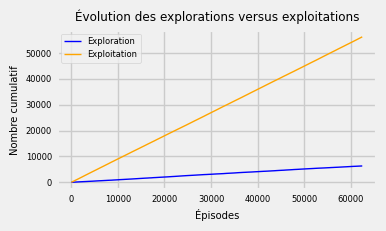

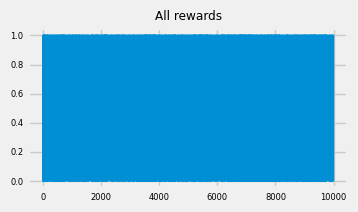

[['BAS' 'DROITE' 'BAS' 'GAUCHE']
 ['BAS' 'HAUT' 'BAS' 'BAS']
 ['DROITE' 'BAS' 'BAS' 'DROITE']
 ['GAUCHE' 'DROITE' 'DROITE' 'BAS']]


In [37]:
desc4= [
    "SFFF",
    "FHFH",
    "FFFH",
    "HFFG"
]

env = gym.make('FrozenLake-v1', desc=desc4, is_slippery=False,render_mode="rgb_array")
env.reset()
#env.render()

nb_actions = env.action_space.n
nb_states = env.observation_space.n

print(f"Nombre d'action : {nb_actions},  Nombre d'états : {nb_states}")

Qtable = init_Qtable(nb_states,nb_actions,opts=False)
Q_table, all_rewards = train(10000, env, 1000, Qtable, gamma=0.9, alpha=0.8, decay_rate=0.01)
optimal_policy = np.argmax(Qtable, axis=1)

# Utiliser la fonction
display_graph(all_rewards)
liste_modifiee = [action_name[element] for element in optimal_policy]

print(np.array(liste_modifiee).reshape(int(np.sqrt(nb_states)), int(np.sqrt(nb_states))))
# 4. Lire la vidéo
display_video(env, path,Q_table,True)


__`Interprétation`__

 - `Récompense = 1` : L’épisode s’est terminé par une réussite (l’agent a atteint le but).
 - `Récompense = 0` : L’agent a échoué (par exemple, tombé dans un trou ou n’a pas atteint le goal).

__`Le graphique est donc un indicateur binaire du succès (1 = succès, 0 = échec) pour chaque essai.`__

- `L'algorithme modification de la valeur de min epsilon peremt d'assurer la continuité de l'exploration.`
 - `La Qtable est initialisée avec des zeros`
 - `Le mode d'exploration s'arrête très tot. ` 
 - `A ce state les rewards sont non pondérés, ce qui justifient transitions de zéro à 1 des récompenses. ` 
 - `Avec 100000 épisodes le robot gagne de tout temps. `
 - `La politique optimale répond au problème posée à l'agent avec une initialisation de la table à zéro.`

In [ ]:
#raise SystemExit("Stop notebook ici")

100%|██████████| 9998/9998 [00:07<00:00, 1263.98it/s]


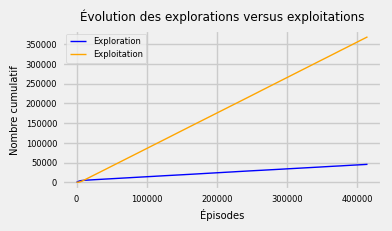

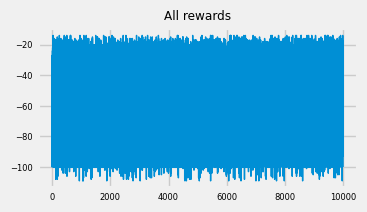

[['DROITE' 'BAS' 'BAS' 'GAUCHE' 'HAUT' 'GAUCHE' 'HAUT' 'DROITE']
 ['BAS' 'GAUCHE' 'DROITE' 'DROITE' 'DROITE' 'HAUT' 'BAS' 'HAUT']
 ['BAS' 'GAUCHE' 'GAUCHE' 'GAUCHE' 'BAS' 'DROITE' 'HAUT' 'DROITE']
 ['GAUCHE' 'BAS' 'DROITE' 'BAS' 'HAUT' 'BAS' 'DROITE' 'HAUT']
 ['BAS' 'HAUT' 'DROITE' 'DROITE' 'GAUCHE' 'DROITE' 'HAUT' 'BAS']
 ['GAUCHE' 'GAUCHE' 'DROITE' 'GAUCHE' 'BAS' 'GAUCHE' 'DROITE' 'HAUT']
 ['GAUCHE' 'GAUCHE' 'GAUCHE' 'GAUCHE' 'DROITE' 'HAUT' 'GAUCHE' 'DROITE']
 ['DROITE' 'GAUCHE' 'DROITE' 'HAUT' 'GAUCHE' 'BAS' 'HAUT' 'BAS']]


: 

In [ ]:
desc8 = [
    "SFFFFFFF",
    "FFFFFFFF",
    "FFFHFFFF",
    "FFFFFHFF",
    "FFFFHFFF",
    "FHFFFFFF",
    "FFFFHFFF",
    "FFFFFHFH"
]

env = gym.make('FrozenLake-v1', desc=desc8, is_slippery=True,render_mode="rgb_array")
env.reset()
env.render()

nb_actions = env.action_space.n
nb_states = env.observation_space.n

P = env.env.env.env.P
new_P = change_rewards(P, move_penalty=-1, hole_penalty=-10, goal_reward=300, flag=False)

Q_table = init_Qtable(nb_states,nb_actions,opts=False)
frozen_Q, all_rewards = train(10000, env, 1000, Q_table, gamma=0.97, alpha=0.001,  decay_rate = 0.99999)

optimal_policy = np.argmax(Q_table, axis=1)
display_graph(all_rewards) 

liste_modifiee = [action_name[element] for element in optimal_policy]
print(np.array(liste_modifiee).reshape(int(np.sqrt(nb_states)), int(np.sqrt(nb_states))))
display_video(env, path,Q_table,False)

Dans cet environnement, la table des rewards est stockée dans un dictionnaire env.env.env.env.P .    
Observez cette table avec la fonction suivante :      
 - on voit quel état est terminal et avec quelle récompense
    - changer la récompense pour les trous
    - changer aussi récompense de faire un pas

N'hésitez pas à aller voir la doc:

https://gymnasium.farama.org/environments/toy_text/frozen_lake/

Dans une 2e partie nous  verrons aussi que l'environnement peut être traité avec des actions non-déterministes (sur la glace on ne contrôle pas toujours ses mouvements !)

64
Qtable.shape : (64, 4) : [[0. 0. 0. 0.]]


100%|██████████| 9998/9998 [00:12<00:00, 783.94it/s]


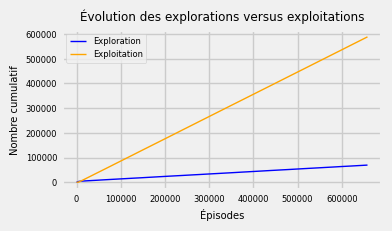

Qtable.shape après entrainement : (64, 4) : [[-8.58227323 -8.40700243 -8.53486599 -8.51228522]]


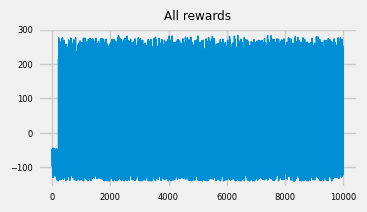

[['BAS' 'DROITE' 'DROITE' 'BAS' 'HAUT' 'DROITE' 'GAUCHE' 'GAUCHE']
 ['HAUT' 'HAUT' 'HAUT' 'HAUT' 'HAUT' 'BAS' 'BAS' 'DROITE']
 ['DROITE' 'GAUCHE' 'GAUCHE' 'GAUCHE' 'DROITE' 'HAUT' 'DROITE' 'DROITE']
 ['GAUCHE' 'GAUCHE' 'GAUCHE' 'BAS' 'GAUCHE' 'GAUCHE' 'DROITE' 'BAS']
 ['GAUCHE' 'HAUT' 'GAUCHE' 'GAUCHE' 'DROITE' 'BAS' 'HAUT' 'DROITE']
 ['GAUCHE' 'GAUCHE' 'GAUCHE' 'DROITE' 'HAUT' 'GAUCHE' 'GAUCHE' 'DROITE']
 ['GAUCHE' 'GAUCHE' 'DROITE' 'HAUT' 'GAUCHE' 'GAUCHE' 'GAUCHE' 'DROITE']
 ['GAUCHE' 'BAS' 'GAUCHE' 'GAUCHE' 'HAUT' 'DROITE' 'BAS' 'GAUCHE']]


In [34]:
desc8=["SFFFFFFF","FFFFFFFF","FFFHFFFF","FFFFFHFF","FFFHFFFF","FHHFFFHF","FHFFHFHF","FFFHFFFG"]
env = gym.make('FrozenLake-v1', desc=desc8, is_slippery=True,render_mode="rgb_array")
env.reset()
#env.render()

nb_actions = env.action_space.n
nb_states = env.observation_space.n
env = gym.make('FrozenLake-v1', desc=desc8, is_slippery=True,render_mode="rgb_array")
print(env.observation_space.n)

P = env.env.env.env.P
new_P = change_rewards(P, move_penalty=-1, hole_penalty=-40, goal_reward=300, flag=False)
Q_table = init_Qtable(env.observation_space.n,env.action_space.n,opts=True)
print(f'Qtable.shape : {Q_table.shape} : {Q_table[0:1]}')
Q_table, all_rewards = train(10000, env, 1000, Q_table, gamma=0.9, alpha=0.3,  decay_rate = 0.99999)
print(f'Qtable.shape après entrainement : {Q_table.shape} : {Q_table[0:1]}')

optimal_policy = np.argmax(Q_table, axis=1)
display_graph(all_rewards) 

liste_modifiee = [action_name[element] for element in optimal_policy]
print(np.array(liste_modifiee).reshape(int(np.sqrt(env.observation_space.n)), int(np.sqrt(env.observation_space.n))))
display_video(env, path,Q_table,False)

`Premier graphique, interprétation`

C’est le comportement attendu pour une bonne politique epsilon-greedy :   
 - beaucoup d’exploration au tout début, puis quasiment que de l’exploitation au fil de l’apprentissage,
 - la politique apprise est progressivement préférée, car l’agent a déjà découvert comment obtenir les meilleures récompenses.
 - Garantie de convergence (si la courbe d’exploration ne devient pas nulle !).

`Utilité` :      
 - Permet de vérifier visuellement que l’agent n’est pas resté bloqué dans l’exploration (par exemple avec un epsilon qui ne décroît pas).

__En résumé__ :     
 - La plupart des décisions sont prises selon la meilleure politique apprise (« exploitation »), ce qui est un comportement optimal une fois la Q-table ait convergé. 
 - La courbe bleu quasi-plate confirme que l’exploration résiduelle est faible, mais non nulle (ce qui reste souhaitable dans la plupart des contextes RL robustes).

`Second graphique, interprétation`

Ce graphique illustre une évolution des récompenses sur 10 000 épisodes, très caractéristique d’un agent Q-learning ayant convergé vers une politique efficace.

`Analyse`: 
 - __Début (<1500 épisodes)__ : Les premières récompenses sont souvent négatives (vers -100), preuve que l’agent tombe, explore encore, ou ne maîtrise pas l’environnement.    
 - __Après la phase d’exploration initiale__ : La quasi-totalité des épisodes aboutissent à des récompenses maximales (ici proches de +275 ou +300 selon la configuration).

C’est typique d’une politique apprise efficace : l’agent atteint très fréquemment l’objectif en minimisant les pénalités.

Très peu d’épisodes à récompense basse après 2000 épisodes :

Cela indique que l’agent exploite quasi exclusivement la meilleure stratégie connue.

`Interprétation`

__Politique apprise quasi optimale__ : 

- L’agent a appris, après une phase d’exploration, à se rendre de manière fiable au but sans tomber dans les trous ou accumuler de pénalités inutiles.
- Énorme réduction de la variance après convergence, presque tous les épisodes réussissent !

Réussite, ce type de courbe est la preuve que la Q-table code une solution efficace, et que le réglage (alpha, gamma, epsilon, decay…) est bon pour la difficulté de la carte.

`À retenir`
 - Cette courbe montre que l’agent maîtrise parfaitement la tâche sur la majorité des épisodes après entraînement.
 - La petite zone négative du début est normale (exploration initiale).
 - C’est un bon résultat sur FrozenLake ou tout environnement RL si on souhaite maximiser la réussite !

In [35]:
def evaluate_agent(env, max_steps, n_episodes, Qtable):
    # doit renvoyer la moyenne et l'écart-type du total des récompenses par épisode
    all_rew = []
    for episode in tqdm(range(n_episodes)):
        state, _ = env.reset()
        total_reward = 0
        for step in range(max_steps):
            # Sélectionner la meilleure action (politique gloutonne)
            action = np.argmax(Qtable[state,:])
            # Faire l'action
            next_state, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            env.render()
            if done or truncated:
                break
            state = next_state
        all_rew.append(total_reward)        
  
    stats = np.array(all_rew)
    std_reward  =  np.std(all_rew)
    mean_reward =  np.mean(all_rew)
    return mean_reward, std_reward

__`SARSA (on-policy)`__ : $\large Q(s,a)←Q(s,a)+α[r+γQ(s^′,a^′)−Q(s,a)]$

`Le terme Q(s′,a′) est la valeur de l'action a′ que l'agent a réellement choisie dans l'état s′`.  
 - Après apprentissage la Q-table est complétée (apprise par exploration).
 - Pour chaque état, l’agent choisit l’action à effectuer en prenant $a^∗ =arg\ max_{a} Q(s,a)$
 - Autrement dit, il reconstitue le “chemin optimal” en suivant, à chaque étape, l’action qui maximise la Q-valeur selon sa table.

 __On-policy__ est souvent préféré pour des tâches où la sécurité et la stabilité pendant l'apprentissage sont cruciales (ex: robotique où les erreurs peuvent être coûteuses).

__`Q-learning (off-policy)`__ : $\large Q(s,a)←Q(s,a)+α[r+γ\ max_{a'})−Q(s,a)]$

`Q-learning utilise la meilleure action possible dans s′, indépendamment de la politique réelle`.     
 - Le terme $max_{a^′}Q(s^′,a^′)$ est la valeur de la meilleure action possible depuis s′, que l'agent l'ait choisie ou non.    

__off-policy__ Généralement privilégié quand les données sont rares ou coûteuses à obtenir, la capacité à réutiliser les expériences passées est un avantage majeur. 

100%|██████████| 9998/9998 [00:11<00:00, 852.11it/s]


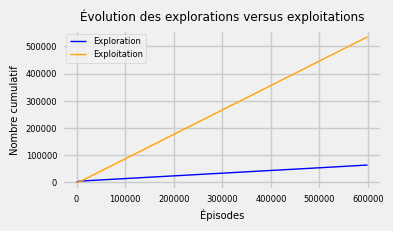

100%|██████████| 500/500 [00:50<00:00,  9.94it/s]


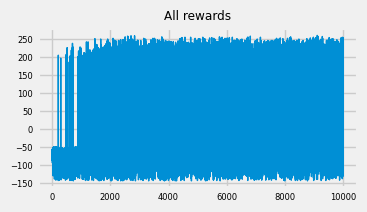

ecart-type : 156.06142302311613 espérance 88.162


In [36]:
# Tester l'agent sur FrozenLake avec is_slippery=True
env = gym.make("FrozenLake-v1",  desc=desc8, is_slippery=True, render_mode="rgb_array")
env.reset()
nb_actions = env.action_space.n
nb_states = env.observation_space.n
P = env.env.env.env.P
#env.render()
Q_table = init_Qtable(nb_states,nb_actions,opts=True)
new_P = change_rewards(P, move_penalty=-1, hole_penalty=-45, goal_reward=275, flag=False)
Q_table, all_rewards = train(10000, env, 500, Q_table, gamma=0.95, alpha=0.02, decay_rate = 0.99999)
mean_reward ,std_reward = evaluate_agent(env,10000,500,Q_table)
display_graph(all_rewards) 
env.close()
print(f'ecart-type : {std_reward} espérance {mean_reward}')

Caractérisitique de l'agent, d’après le graphique et les statistiques :

`Écart-type (152.33)`

 - Dispersion importante :
 - Les récompenses individuelles varient beaucoup d’un épisode à l’autre :
 
__Certains épisodes reçoivent des scores très élevés (goal atteint), mais il existe encore beaucoup de scores négatifs ou très bas (échecs/chutes/intermédiaires). Cela traduit l'instabilité persistante due à la nature stochastique/glissante du problème FrozenLake (malgré une politique majoritairement efficace)__.

`Espérance Positive et assez élevée  (102.21)`

 - Cela veut dire que l'agent réussit régulièrement à obtenir de bons scores !
 - La politique apprise par ton RL semble globalement efficace 
 
__Cela signifie que sur cette carte/configuration : la majorité des épisodes aboutissent à des résultats positifs (souvent l’objectif atteint).__

__Conclusion sur le comportement de l'agent__

 - Grande dispersion des scores
    - `performances irrégulières`
 - Moyenne faible
    - `la politique apprise n’est pas très efficace sur cette carte`
    - `beaucoup d’épisodes ratés`
    - `politique loin d’être optimale`

`Le système fonctionne en mode is_sliperry=True`